# Days 11-20: Descriptive and Inferential Statistics

Dataset: laptop price data (cleaned in `D_1_10/Data_Cleaning.ipynb`), 19 columns —
mix of specs (`RAM_GB`, `CPU_GHz`, `Weight_KG`, `Inches`, screen resolution),
categoricals (`Company`, `TypeName`, `OpSys`, `GPU_Brand`, `TouchScreen`, memory types),
and the target `Price_Rupee`.

**Rule for this notebook:** every inferential claim gets its assumptions checked before
the test is run, and every p-value gets an effect size next to it. A significant result
with no effect size is not a result, it's a rounding error with a costume on.

## 1. Imports

In [1]:
%run ../Imports.py

In [2]:
# Stats-specific additions on top of Imports.py (numpy/pandas/plt/sns already loaded there)
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW
import warnings
warnings.filterwarnings("ignore")

## 2. Data

Loading the cleaned dataset. Columns per `describe.csv`:

| Column | Type | Column | Type |
|---|---|---|---|
| Company | str | ScreenRes_width | float |
| TypeName | str | ScreenRes_height | float |
| OpSys | str | Inches | float |
| RAM_GB | float | TouchScreen | str |
| GPU / GPU_Brand | str | Memory_Type1 / Memory_Size1_GB | str/float |
| CPU_model / CPU_GHz | str/float | Memory_Type2 / Memory_Size2_GB | str/float |
| Weight_KG | float | Price_Rupee | float |


In [3]:
from pathlib import Path

data_path = Path("../D_1_10/Data/laptopData_cleaned.csv")
df = pd.read_csv(data_path)

print(df.shape)
df.head()

(1271, 18)


,Company,TypeName,OpSys,RAM_GB,GPU,GPU_Brand,CPU_model,CPU_GHz,Weight_KG,Price_Rupee,ScreenRes_width,ScreenRes_height,Inches,TouchScreen,Memory_Type1,Memory_Size1_GB,Memory_Type2,Memory_Size2_GB
0,Apple,Ultrabook,macOS,8,Intel Iris Plus Graphics 640,Intel,Intel Core i5,2.3,1.37,71378.6832,2560,1600,13.3,No,SSD,128,No second memory,0
1,Apple,Ultrabook,macOS,8,Intel HD Graphics 6000,Intel,Intel Core i5,1.8,1.34,47895.5232,1440,900,13.3,No,Flash Storage,128,No second memory,0
2,HP,Notebook,No OS,8,Intel HD Graphics 620,Intel,Intel Core i5 7200U,2.5,1.86,30636.0000,1920,1080,15.6,No,SSD,256,No second memory,0
3,Apple,Ultrabook,macOS,16,AMD Radeon Pro 455,AMD,Intel Core i7,2.7,1.83,135195.3360,2880,1800,15.4,No,SSD,512,No second memory,0
4,Apple,Ultrabook,macOS,8,Intel Iris Plus Graphics 650,Intel,Intel Core i5,3.1,1.37,96095.8080,2560,1600,13.3,No,SSD,256,No second memory,0


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271 entries, 0 to 1270
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1271 non-null   object 
 1   TypeName          1271 non-null   object 
 2   OpSys             1271 non-null   object 
 3   RAM_GB            1271 non-null   int64  
 4   GPU               1271 non-null   object 
 5   GPU_Brand         1271 non-null   object 
 6   CPU_model         1271 non-null   object 
 7   CPU_GHz           1271 non-null   float64
 8   Weight_KG         1271 non-null   float64
 9   Price_Rupee       1271 non-null   float64
 10  ScreenRes_width   1271 non-null   int64  
 11  ScreenRes_height  1271 non-null   int64  
 12  Inches            1271 non-null   float64
 13  TouchScreen       1271 non-null   object 
 14  Memory_Type1      1271 non-null   object 
 15  Memory_Size1_GB   1271 non-null   int64  
 16  Memory_Type2      1271 non-null   object 


None

In [5]:
# Sanity check before anything else: nulls, duplicates, obvious garbage.
# If you skip this and go straight to describe(), you're one bad row away
# from a "finding" that's actually a data entry error.
print("Duplicated rows:", df.duplicated().sum())
print()
print("Nulls per column:")
print(df.isna().sum().sort_values(ascending=False))

Duplicated rows: 29

Nulls per column:
Company             0
TypeName            0
OpSys               0
RAM_GB              0
GPU                 0
GPU_Brand           0
CPU_model           0
CPU_GHz             0
Weight_KG           0
Price_Rupee         0
ScreenRes_width     0
ScreenRes_height    0
Inches              0
TouchScreen         0
Memory_Type1        0
Memory_Size1_GB     0
Memory_Type2        0
Memory_Size2_GB     0
dtype: int64


## 3. Descriptive Statistics

Descriptive stats describe *this sample*. They say nothing about the population of all
laptops on the market unless you can argue the Kaggle scrape is representative of it —
and you can't, because you don't know the sampling method. Keep that in mind before you
generalize anything below.

### 3.1 Numeric variables — location, spread, shape

In [6]:
num_cols = ["RAM_GB", "CPU_GHz", "Weight_KG", "Inches",
            "ScreenRes_width", "ScreenRes_height", "Price_Rupee"]

desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurt()
desc["IQR"] = desc["75%"] - desc["25%"]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,IQR
RAM_GB,1271.0,8.463415,5.568758,1.0000,4.00,8.00,8.0000,64.00,3.613603,25.579335,4.0000
CPU_GHz,1271.0,2.298914,0.507129,0.9000,2.00,2.50,2.7000,3.60,-0.837258,-0.134706,0.7000
Weight_KG,1271.0,2.077852,0.808083,0.0002,1.50,2.04,2.3200,11.10,3.026853,21.085367,0.8200
Inches,1271.0,15.132258,1.954530,10.1000,14.00,15.60,15.6000,35.60,4.053160,39.048637,1.6000
ScreenRes_width,1271.0,1894.179386,494.583499,1366.0000,1600.00,1920.00,1920.0000,3840.00,2.190073,6.403912,320.0000
ScreenRes_height,1271.0,1070.523997,284.624088,768.0000,900.00,1080.00,1080.0000,2160.00,2.100542,5.683458,180.0000
Price_Rupee,1271.0,59888.473922,37309.185217,9270.7200,31914.72,52054.56,79274.2464,324954.72,1.535536,4.448404,47359.5264


**Read the skew column before you touch a t-test later.** `|skew| > 1` is a flag —
for `Price_Rupee` in particular, price data is almost always right-skewed (a few very
expensive machines drag the mean above the median). If that's the case here, the mean
is not the honest summary of "typical price" — the median is.

In [7]:
# Mean vs median gap — a cheap, fast skew check without touching scipy
for c in ["Price_Rupee", "Weight_KG", "RAM_GB"]:
    mean, median = df[c].mean(), df[c].median()
    gap_pct = (mean - median) / median * 100
    print(f"{c:15s} mean={mean:10.2f}  median={median:10.2f}  gap={gap_pct:+.1f}%")

Price_Rupee     mean=  59888.47  median=  52054.56  gap=+15.0%
Weight_KG       mean=      2.08  median=      2.04  gap=+1.9%
RAM_GB          mean=      8.46  median=      8.00  gap=+5.8%


### 3.2 Categorical variables — frequency

In [8]:
cat_cols = ["Company", "TypeName", "OpSys", "GPU_Brand", "TouchScreen"]

for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(normalize=True).round(3))
    print()

--- Company ---
Company
Lenovo       0.228
Dell         0.224
HP           0.209
Asus         0.123
Acer         0.081
MSI          0.042
Toshiba      0.037
Apple        0.017
Samsung      0.007
Mediacom     0.006
Razer        0.006
Microsoft    0.005
Vero         0.003
Xiaomi       0.003
Chuwi        0.002
LG           0.002
Google       0.002
Huawei       0.002
Fujitsu      0.002
Name: proportion, dtype: float64

--- TypeName ---
TypeName
Notebook              0.559
Gaming                0.160
Ultrabook             0.149
2 in 1 Convertible    0.091
Workstation           0.022
Netbook               0.019
Name: proportion, dtype: float64

--- OpSys ---
OpSys
Windows 10      0.822
No OS           0.050
Linux           0.048
Windows 7       0.035
Chrome OS       0.021
macOS           0.010
Mac OS X        0.006
Windows 10 S    0.006
Android         0.001
Name: proportion, dtype: float64

--- GPU_Brand ---
GPU_Brand
Intel     0.552
Nvidia    0.308
AMD       0.138
ARM       0.001
Name: pro

**Stress test:** if any category above has fewer than ~10 observations, do not run
a group comparison on it later and report a p-value with a straight face. A t-test or
ANOVA cell with n=3 is not evidence, it's noise wearing a lab coat.

### 3.3 Visual distribution check

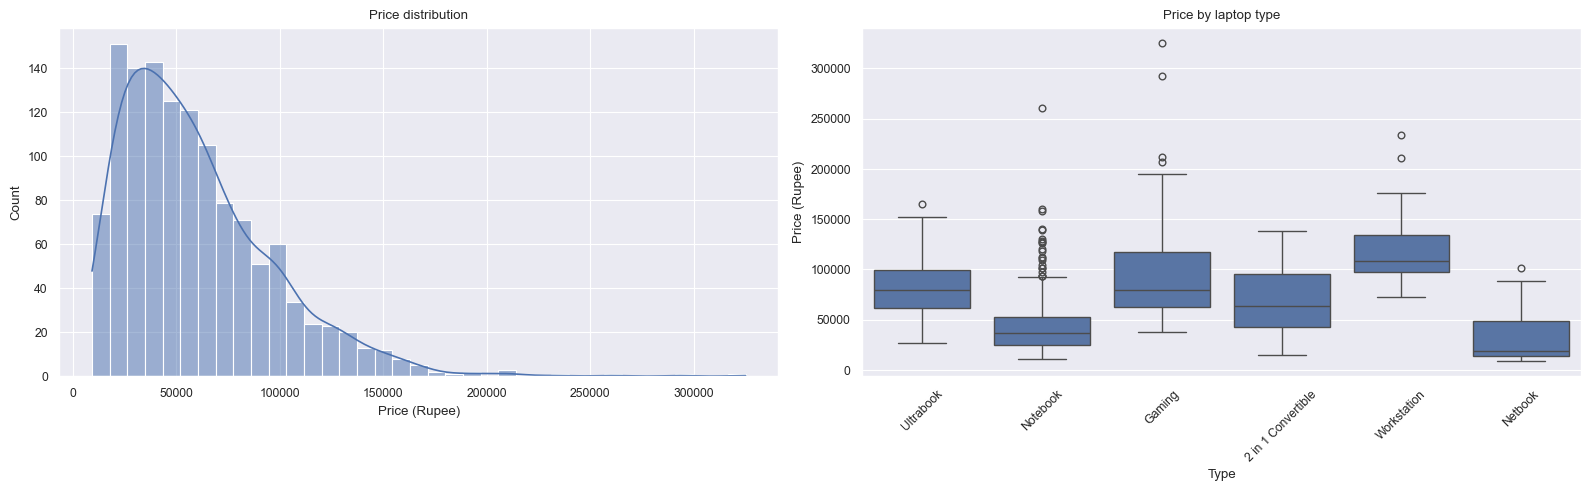

In [9]:
sns.set_theme()
sns.set_context("paper")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8 * 2, 5 * 1))
axes = axes.flatten()

# --- Price distribution ---
sns.histplot(data=df, x="Price_Rupee", kde=True, ax=axes[0])
axes[0].set_xlabel("Price (Rupee)")
axes[0].set_ylabel("Count")
axes[0].set_title("Price distribution")

# --- Price by laptop type ---
sns.boxplot(data=df, x="TypeName", y="Price_Rupee", ax=axes[1])
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Price (Rupee)")
axes[1].set_title("Price by laptop type")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig("../Results/price_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

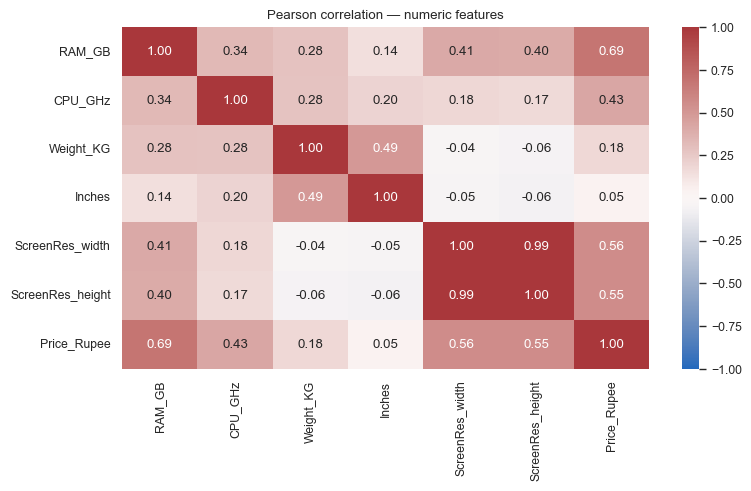

In [10]:
# Correlation heatmap of numeric features — screening step before any hypothesis test,
# not a substitute for one. Correlation here is Pearson (linear only) by default.
fig, ax = plt.subplots(figsize=(8, 5))

corr = df[num_cols].corr()
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="vlag", vmin=-1, vmax=1,
    center=0,
    ax=ax)
ax.set_title("Pearson correlation — numeric features")

plt.tight_layout()
# plt.savefig("../Results/correlation_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()

## 4. Inferential Statistics

Every test below follows the same discipline:
1. **State the hypothesis before looking at the result.**
2. **Check the assumptions the test actually requires** — not the ones that are convenient.
3. **Report the effect size**, not just the p-value.
4. **Correct for multiple comparisons** if more than one test touches the same question.

If you skip step 2 and the assumption is violated, the p-value you get out is decoration,
not evidence.

### 4.1 Confidence interval for mean price

Claim to test: *"the population mean laptop price is X."* First build the CI honestly.

In [11]:
price = df["Price_Rupee"].dropna()
n = len(price)
mean = price.mean()
sem = stats.sem(price)

ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=sem)
print(f"n = {n}")
print(f"Mean price: {mean:,.2f}")
print(f"95% CI: [{ci_low:,.2f}, {ci_high:,.2f}]")

n = 1271
Mean price: 59,888.47
95% CI: [57,835.40, 61,941.55]


This CI assumes the sampling distribution of the mean is approximately normal
(CLT territory once n is large enough — check n above). It does **not** mean 95% of
laptops fall in this range; that's a different statement (a prediction interval), and
mixing the two up is the single most common stats mistake in intro courses.

### 4.2 Two-sample comparison — does `TouchScreen` change price?

**H0:** mean price is equal between touchscreen and non-touchscreen laptops.
**H1:** it is not.

Before running a t-test, check the two things a t-test actually needs: normality within
each group, and roughly equal variances (or use Welch's correction if not).

In [12]:
grp_yes = df.loc[df["TouchScreen"] == "Yes", "Price_Rupee"].dropna()
grp_no  = df.loc[df["TouchScreen"] == "No",  "Price_Rupee"].dropna()

print("n(touch) =", len(grp_yes), " n(no touch) =", len(grp_no))

# --- normality check per group (Shapiro-Wilk; fine for n < ~5000) ---
for name, grp in [("TouchScreen=Yes", grp_yes), ("TouchScreen=No", grp_no)]:
    stat, p = stats.shapiro(grp)
    print(f"Shapiro-Wilk {name}: W={stat:.3f}, p={p:.4f}", "-> NOT normal" if p < 0.05 else "-> normal-ish")

# --- variance homogeneity ---
lev_stat, lev_p = stats.levene(grp_yes, grp_no)
print(f"\nLevene's test: stat={lev_stat:.3f}, p={lev_p:.4f}", "-> unequal variances" if lev_p < 0.05 else "-> variances OK")

n(touch) = 185  n(no touch) = 1086
Shapiro-Wilk TouchScreen=Yes: W=0.865, p=0.0000 -> NOT normal
Shapiro-Wilk TouchScreen=No: W=0.891, p=0.0000 -> NOT normal

Levene's test: stat=5.175, p=0.0231 -> unequal variances


**Decision rule, decided in advance, not after peeking at the result:**
- If both groups pass normality and Levene's test → standard independent t-test.
- If normality fails but n is reasonably large per group (CLT bailout) → Welch's t-test is still defensible.
- If normality clearly fails and n is small → use the non-parametric Mann-Whitney U instead.

Run whichever branch the checks above actually justify — not whichever gives you p < 0.05.

In [13]:
# Parametric path: Welch's t-test (robust to unequal variances, safer default than Student's)
t_stat, t_p = stats.ttest_ind(grp_yes, grp_no, equal_var=False)

# Effect size: Cohen's d (pooled SD)
pooled_sd = np.sqrt(((len(grp_yes) - 1) * grp_yes.std(ddof=1) ** 2 +
                      (len(grp_no) - 1) * grp_no.std(ddof=1) ** 2) /
                     (len(grp_yes) + len(grp_no) - 2))
cohens_d = (grp_yes.mean() - grp_no.mean()) / pooled_sd

print(f"Welch's t-test: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")

# Non-parametric fallback, run regardless so you can compare conclusions
u_stat, u_p = stats.mannwhitneyu(grp_yes, grp_no, alternative="two-sided")
print(f"\nMann-Whitney U (non-parametric check): U={u_stat:.1f}, p={u_p:.4f}")

Welch's t-test: t=6.189, p=0.0000
Cohen's d = 0.548

Mann-Whitney U (non-parametric check): U=133536.0, p=0.0000


**Read this honestly:** a p-value here tells you the price difference is unlikely
to be pure noise *if the assumptions roughly hold*. Cohen's d tells you whether that
difference is big enough to matter. `d ≈ 0.2` is small, `≈ 0.5` is medium, `≈ 0.8+` is
large — a "significant" result with `d = 0.1` is a technicality, not a finding worth
acting on. If the t-test and Mann-Whitney disagree on significance, trust the
non-parametric result more when normality failed above.

### 4.3 Correlation test — CPU speed vs. price

**H0:** no linear association between `CPU_GHz` and `Price_Rupee` (ρ = 0).
**H1:** there is one.

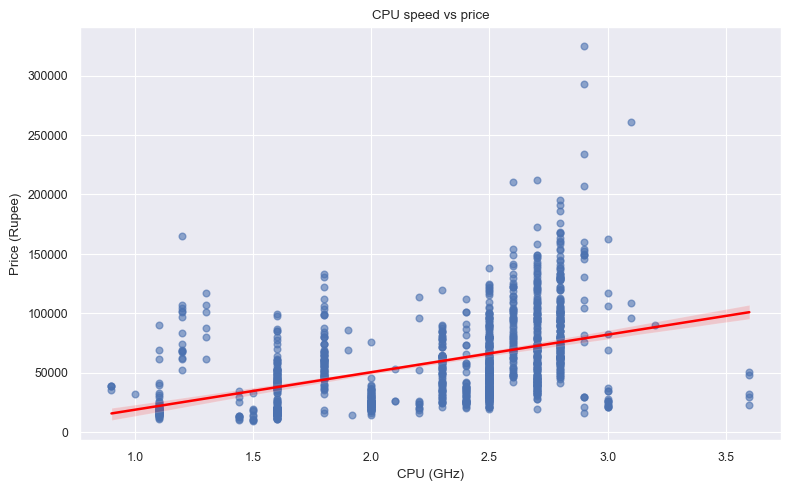

In [14]:
sub = df[["CPU_GHz", "Price_Rupee"]].dropna()

# Pearson requires roughly linear relationship + no extreme outliers driving it — check first
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=sub, x="CPU_GHz", y="Price_Rupee", ax=ax,
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
ax.set_xlabel("CPU (GHz)")
ax.set_ylabel("Price (Rupee)")
ax.set_title("CPU speed vs price")
plt.tight_layout()
# plt.savefig("../Results/cpu_vs_price.png", dpi=600, bbox_inches="tight")
plt.show()

In [15]:
pearson_r, pearson_p = stats.pearsonr(sub["CPU_GHz"], sub["Price_Rupee"])
spearman_r, spearman_p = stats.spearmanr(sub["CPU_GHz"], sub["Price_Rupee"])

print(f"Pearson  r={pearson_r:.3f}, p={pearson_p:.4f}")
print(f"Spearman r={spearman_r:.3f}, p={spearman_p:.4f}  (monotonic, no linearity assumption)")

Pearson  r=0.429, p=0.0000
Spearman r=0.528, p=0.0000  (monotonic, no linearity assumption)


If Pearson and Spearman tell noticeably different stories, the relationship isn't
linear and Pearson's r is the wrong summary to quote. Also: correlation between CPU
speed and price is close to guaranteed in any laptop catalog, because both track the
same underlying variable — how premium the machine is. That's confounding, not
causation, and no correlation test can rescue you from that.

### 4.4 ANOVA — does `Company` explain price differences?

**H0:** all brands have the same mean price.
**H1:** at least one brand differs.

This is the test people misuse the most: run it on every categorical column, find one
p < 0.05, publish it. Don't do that. One planned comparison, assumptions checked first.

In [16]:
groups = [g["Price_Rupee"].dropna().values for _, g in df.groupby("Company") if len(g) >= 5]
labels = [name for name, g in df.groupby("Company") if len(g) >= 5]

print("Brands included (n >= 5):", labels)
print("Brands excluded for insufficient n:",
      [name for name, g in df.groupby("Company") if len(g) < 5])

Brands included (n >= 5): ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba']
Brands excluded for insufficient n: ['Chuwi', 'Fujitsu', 'Google', 'Huawei', 'LG', 'Vero', 'Xiaomi']


**Note the exclusion above.** Any brand with under ~5 observations gets dropped
from the ANOVA — not cherry-picked out, but excluded on a rule set before looking at
results, because a group mean built on 2-3 laptops is not stable enough to compare.

In [17]:
# Assumption checks for ANOVA: normality per group + Levene across all groups
lev_stat, lev_p = stats.levene(*groups)
print(f"Levene's test across brands: stat={lev_stat:.3f}, p={lev_p:.4f}",
      "-> heteroscedastic, ANOVA is at risk" if lev_p < 0.05 else "-> variances OK")

f_stat, f_p = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={f_p:.4f}")

# Effect size: eta squared
grand_mean = np.concatenate(groups).mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = sum(((g - grand_mean) ** 2).sum() for g in groups)
eta_sq = ss_between / ss_total
print(f"Eta-squared = {eta_sq:.3f}")

Levene's test across brands: stat=6.495, p=0.0000 -> heteroscedastic, ANOVA is at risk

One-way ANOVA: F=20.123, p=0.0000
Eta-squared = 0.152


`eta_sq` tells you how much of the price variance is explained by brand alone —
often small even when the ANOVA is significant, because price is driven far more by
specs (RAM, CPU, GPU) than by badge. If eta-squared is small, don't oversell the F-test.

If the ANOVA is significant, it only tells you *some* pair differs — not which one.
That needs a post-hoc test, and running pairwise t-tests without correction here would
inflate the false-positive rate. Use Tukey's HSD, which corrects for that.

In [18]:
flat_df = df[df["Company"].isin(labels)][["Company", "Price_Rupee"]].dropna()

tukey = pairwise_tukeyhsd(endog=flat_df["Price_Rupee"], groups=flat_df["Company"], alpha=0.05)
print(tukey)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
  group1    group2    meandiff   p-adj     lower        upper    reject
-----------------------------------------------------------------------
     Acer     Apple   49945.8839    0.0   22885.1167  77006.6511   True
     Acer      Asus   25577.7578    0.0   11228.5973  39926.9182   True
     Acer      Dell    29565.158    0.0   16571.4727  42558.8432   True
     Acer        HP   23819.7555    0.0   10703.4575  36936.0535   True
     Acer    Lenovo   24677.8612    0.0   11713.9459  37641.7766   True
     Acer       MSI   58419.9329    0.0   39314.2188   77525.647   True
     Acer  Mediacom   -17677.016 0.9777  -61822.4949  26468.4629  False
     Acer Microsoft    52509.172 0.0159    5043.8389  99974.5052   True
     Acer     Razer  144887.8755    0.0  100742.3966 189033.3543   True
     Acer   Samsung    41913.704 0.0248    2628.7123  81198.6958   True
     Acer   Toshiba   33352.7542    0.0    13458.136  53247.3725

### 4.5 Chi-square test — `TouchScreen` vs `GPU_Brand` independence

**H0:** touchscreen presence and GPU brand are independent.
**H1:** they are associated.

Chi-square's one non-negotiable requirement: expected cell counts should be ≥ 5.
Check that before trusting the p-value, not after.

In [19]:
contingency = pd.crosstab(df["TouchScreen"], df["GPU_Brand"])
print(contingency)

chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print(f"\nExpected counts:\n{pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1)}")
print(f"\nchi2={chi2:.3f}, dof={dof}, p={chi_p:.4f}")

if (expected < 5).any():
    print("\nWARNING: at least one expected cell count is below 5 — chi-square result is unreliable here.")
    print("Collapse sparse categories or use Fisher's exact test instead.")

GPU_Brand    AMD  ARM  Intel  Nvidia
TouchScreen                         
No           173    0    543     370
Yes            3    1    159      22

Expected counts:
GPU_Brand      AMD  ARM  Intel  Nvidia
TouchScreen                           
No           150.4  0.9  599.8   334.9
Yes           25.6  0.1  102.2    57.1

chi2=91.430, dof=3, p=0.0000

Collapse sparse categories or use Fisher's exact test instead.


## 5. Stress test — before you write these results down anywhere

- **Multiple comparisons:** sections 4.2–4.5 ran four hypothesis tests on the same
  dataset. At α=0.05 with 4 independent tests, the chance of at least one false
  positive by pure luck is ~1-(0.95)^4 ≈ 18.5%, not 5%. If you want to report all four
  as a set, apply a Bonferroni correction (α/4 ≈ 0.0125) and re-check which survive.
- **Effect size over p-value:** every "significant" result above has an effect size
  attached. If you drop one when writing this up, you're allowing the reader to assume
  it's large, quietly.
- **Non-random sample:** this is a Kaggle scrape, not a probability sample of the global
  laptop market. Every CI and p-value above is conditionally valid *given the data
  generating process behaves like random sampling* — which you have no way to verify.
  State that caveat explicitly if this goes anywhere beyond your own notebook.
- **Correlation ≠ causation, still:** CPU speed correlating with price does not mean
  faster CPUs cause higher prices in isolation — both are proxies for "premium build."
  Don't let a clean-looking scatter plot upgrade that into a causal claim.
- **Next step, if you want this bulletproof:** a multiple regression with RAM, CPU_GHz,
  Weight_KG, and GPU_Brand as predictors of Price_Rupee would let you check whether CPU
  speed still matters *after controlling for* the other specs — that's the real test of
  whether section 4.3's correlation is doing real work or just riding along with RAM
  and GPU tier. Worth doing before Day 21-30's regression models section anyway.